# Semi-Supervised and Self-Supervised Learning

## Learning Objectives
- Understand the motivation and basic concepts of semi-supervised and self-supervised learning.
- Learn typical use cases and algorithmic ideas.

## Introduction
Semi-supervised learning uses a small amount of labeled data supplemented by a large volume of unlabeled data. Self-supervised learning creates its own supervisory signals, enabling learning without manual labels.

## Core Concepts
- **Semi-Supervised Learning:** Combines labeled and unlabeled data.
- **Self-Supervised Learning:** Generates labels from the data itself.
- **Use Cases:** Image recognition, NLP, speech.
- **Typical Methods:** Pseudo-labeling, contrastive learning.


In [1]:
from sklearn.datasets import make_moons
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC
import numpy as np

# Generate synthetic data
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Mask some training data as unlabeled (-1)
rng = np.random.RandomState(42)
labeled_idx = rng.choice(range(300), 30, replace=False)
y_train = np.full(shape=300, fill_value=-1)
y_train[labeled_idx] = y[labeled_idx]

# Create base classifier
base_clf = SVC(kernel='rbf', probability=True, random_state=42)

# Create self-training classifier
self_training_clf = SelfTrainingClassifier(
    base_clf,
    threshold=0.75,
    verbose=True
)

# Train model
self_training_clf.fit(X, y_train)

print(f"Labeled samples: {len(labeled_idx)}")
print(f"Unlabeled samples: {len(y_train) - len(labeled_idx)}")
print(f"Total samples after self-training: {len(self_training_clf.labeled_iter_)}")

End of iteration 1, added 188 new labels.
End of iteration 2, added 56 new labels.
End of iteration 3, added 7 new labels.
End of iteration 4, added 3 new labels.
End of iteration 5, added 3 new labels.
End of iteration 6, added 1 new labels.
Labeled samples: 30
Unlabeled samples: 270
Total samples after self-training: 300


More robust example

End of iteration 1, added 156 new labels.
End of iteration 2, added 36 new labels.
End of iteration 3, added 4 new labels.

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.81      0.88        26
           1       0.87      0.97      0.92        34

    accuracy                           0.90        60
   macro avg       0.91      0.89      0.90        60
weighted avg       0.91      0.90      0.90        60

Accuracy: 0.900


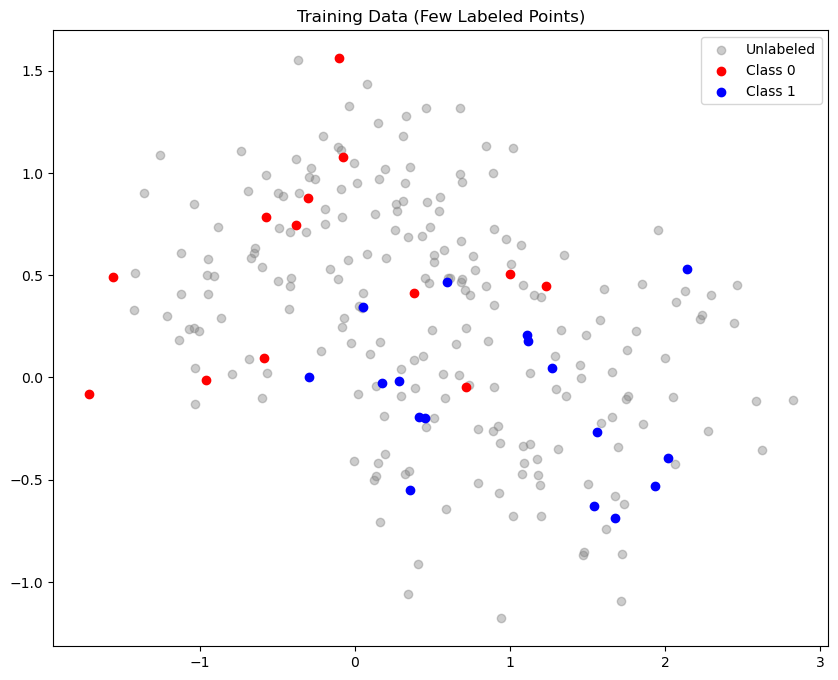

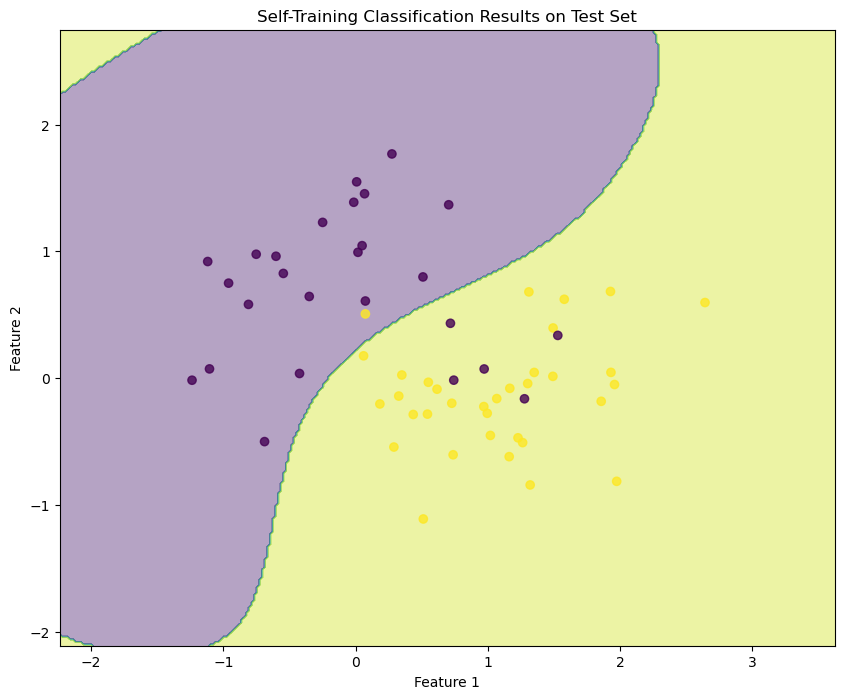

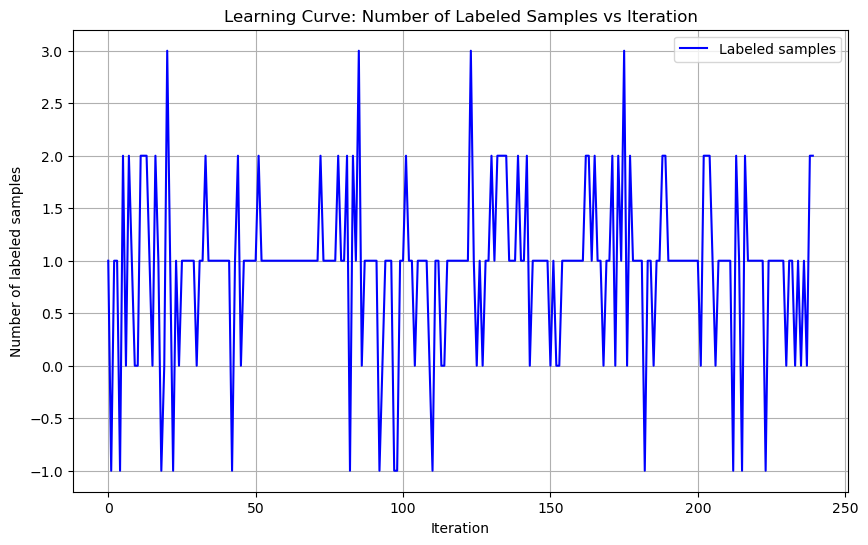

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

import matplotlib.pyplot as plt

# Split data into test set for final evaluation
X_train, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Only use small portion of training data as labeled
n_labeled = 30
labeled_idx = np.random.RandomState(42).choice(range(len(y_train_full)), n_labeled, replace=False)
y_train = np.full(shape=len(y_train_full), fill_value=-1)
y_train[labeled_idx] = y_train_full[labeled_idx]

# Train self-training classifier
base_clf = SVC(kernel='rbf', probability=True, random_state=42)
self_training_clf = SelfTrainingClassifier(
    base_clf, 
    threshold=0.75,
    verbose=True
)

# Fit model
self_training_clf.fit(X_train, y_train)

# Make predictions
y_pred = self_training_clf.predict(X_test)

# Print metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Visualize decision boundary
def plot_decision_boundary(X, y, model, title="Decision Boundary"):
    h = 0.02  # Step size in mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10,8))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Plot original data with few labeled points
plt.figure(figsize=(10,8))
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], c='gray', 
           label='Unlabeled', alpha=0.4)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red',
           label='Class 0')  
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue',
           label='Class 1')
plt.title("Training Data (Few Labeled Points)")
plt.legend()
plt.show()

# Plot decision boundary
plot_decision_boundary(X_test, y_test, self_training_clf, 
                      "Self-Training Classification Results on Test Set")

# Plot learning curve
n_iters = len(self_training_clf.labeled_iter_)
plt.figure(figsize=(10,6))
plt.plot(range(n_iters), self_training_clf.labeled_iter_, 'b-', label='Labeled samples')
plt.xlabel('Iteration')
plt.ylabel('Number of labeled samples')
plt.title('Learning Curve: Number of Labeled Samples vs Iteration')
plt.legend()
plt.grid()
plt.show()

## Exercise
Research and summarize a self-supervised learning method such as contrastive learning.

In [ ]:
# Your notes here

## Summary
- Semi-supervised and self-supervised learning reduce dependency on labeled data.
- Growing research area with significant impact.


## Further Reading
- [Survey on Semi-Supervised Learning](https://arxiv.org/abs/1908.02983)
- [Self-Supervised Learning Overview](https://arxiv.org/abs/2006.08218)
